In [8]:
# %pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("datasets/round2/prices_round_2_day_1.csv", delimiter=";")

# tickers = ["EMERALDS", "TOMATOES"] # Tutorial round 
tickers = ["INTARIAN_PEPPER_ROOT", "ASH_COATED_OSMIUM"] # Round 1
 
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1,0,INTARIAN_PEPPER_ROOT,12993.0,9.0,12990.0,25.0,NaN,NaN,13007.0,9.0,13010.0,25.0,NaN,NaN,13000.0,0.0
1,1,0,ASH_COATED_OSMIUM,10000.0,13.0,9998.0,21.0,NaN,NaN,10016.0,13.0,10019.0,21.0,NaN,NaN,10008.0,0.0
2,1,100,INTARIAN_PEPPER_ROOT,12993.0,8.0,NaN,NaN,NaN,NaN,13007.0,8.0,13010.0,22.0,NaN,NaN,13000.0,0.0
3,1,100,ASH_COATED_OSMIUM,10000.0,15.0,9998.0,26.0,NaN,NaN,10019.0,26.0,NaN,NaN,NaN,NaN,10009.5,0.0
4,1,200,ASH_COATED_OSMIUM,10000.0,15.0,9998.0,30.0,NaN,NaN,10019.0,30.0,NaN,NaN,NaN,NaN,10009.5,0.0


In [12]:
prices = df.pivot(index="timestamp", columns="product", values="mid_price")

for ticker in tickers:
    clean = prices[ticker][prices[ticker] > 0].dropna()

    print("=" * 5 + ticker + "=" * 5)
    print(clean.describe())
    print()

=====INTARIAN_PEPPER_ROOT=====
count     9984.000000
mean     13500.057342
std        288.746423
min      12995.000000
25%      13250.500000
50%      13500.500000
75%      13750.125000
max      14003.000000
Name: INTARIAN_PEPPER_ROOT, dtype: float64

=====ASH_COATED_OSMIUM=====
count     9978.000000
mean     10000.205402
std          5.018676
min       9980.000000
25%       9997.000000
50%      10000.000000
75%      10004.000000
max      10019.000000
Name: ASH_COATED_OSMIUM, dtype: float64



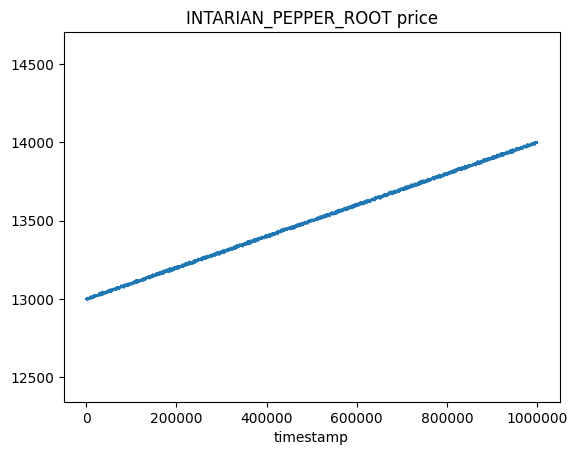

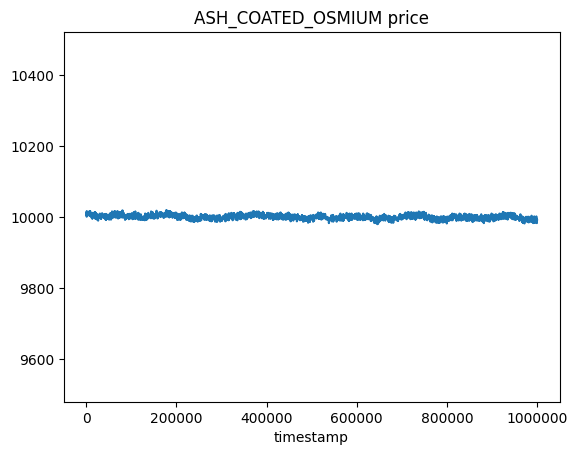

In [10]:

for ticker in tickers:
    # Filter out rows where mid_price is 0 or NaN
    clean = prices[ticker]
    clean = clean[clean > 0]      # removes zeros
    clean = clean.dropna()        # removes NaN (probably already gone but just in case)

    ax = clean.plot(
        title=f"{ticker} price",
        ylim=(clean.min() * 0.95, clean.max() * 1.05),
    )
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.show()

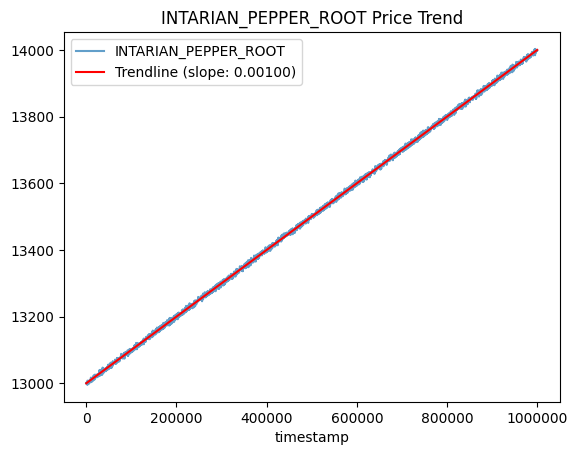

The overall trend step per timestamp tick is: 0.00100
The intercept of the trendline is: 12999.92


In [11]:
import numpy as np

ticker = "INTARIAN_PEPPER_ROOT"
clean = prices[ticker][prices[ticker] > 0].dropna()

# Fit a linear regression line to find the overall trend
x = clean.index.values
y = clean.values

slope, intercept = np.polyfit(x, y, 1)

# Plot the actual price and the trendline
plt.figure()
ax = clean.plot(label=ticker, alpha=0.7)
trendline = slope * x + intercept
plt.plot(x, trendline, color='red', label=f'Trendline (slope: {slope:.5f})')
plt.title(f"{ticker} Price Trend")
ax.ticklabel_format(axis="x", style="plain", useOffset=False)
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.legend()
plt.show()

print(f"The overall trend step per timestamp tick is: {slope:.5f}")
print(f"The intercept of the trendline is: {intercept:.2f}")